# Parkinson's Disease Classification using PCA and SVM

## Task 1: Data Exploration and PCA

In [1]:
import pandas as pd 

#loading datasets

high_train = pd.read_csv("parkinsons_HighHNR_training-2.csv")
high_test = pd.read_csv("parkinsons_HighHNR_test-1.csv")
low_train = pd.read_csv("parkinsons_LowHNR_training-1.csv")
low_test = pd.read_csv("parkinsons_LowHNR_test-1.csv")

#splitting features and labels

X_high_train = high_train.iloc[:, 2:]
y_high_train = high_train.iloc[:, 1]

X_high_test = high_test.iloc[:, 2:]
y_high_test = high_test.iloc[:, 1]

X_low_train = low_train.iloc[:, 2:]
y_low_train = low_train.iloc[:, 1]

X_low_test = low_test.iloc[:, 2:]
y_low_test = low_test.iloc[:, 1]

print ("Loaded successfully")


Loaded successfully


### Scatter Plot Analysis

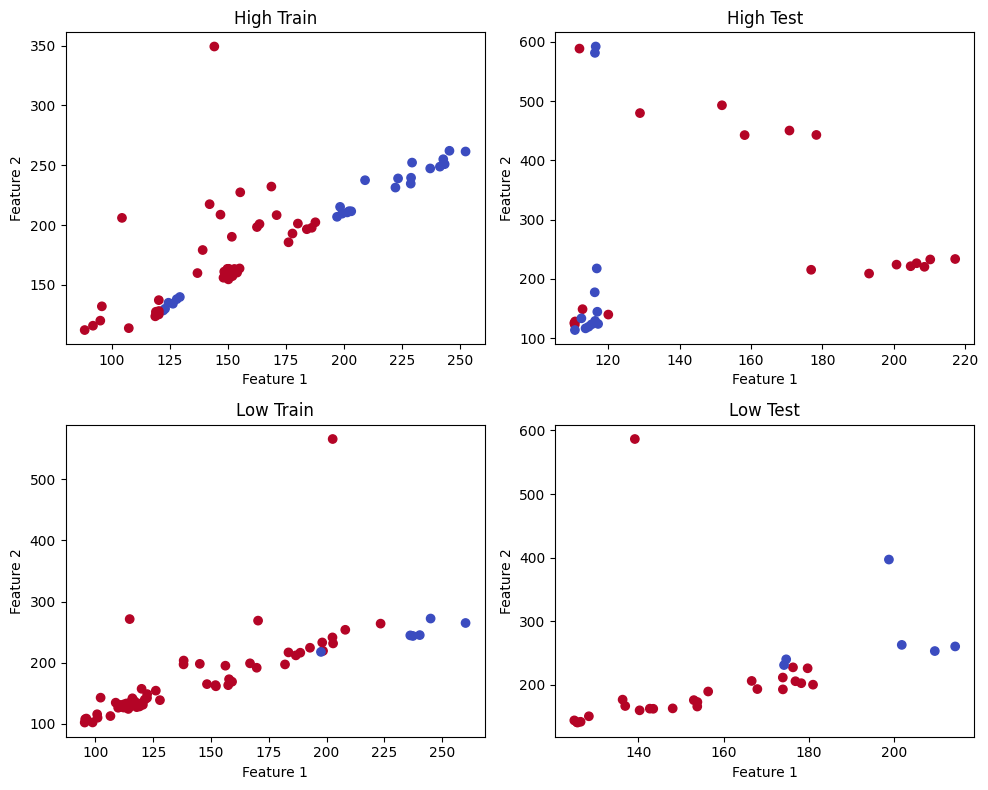

In [2]:
import matplotlib.pyplot as plt

feature1 = 0
feature2 = 1

datasets = [
    (X_high_train, y_high_train, "High Train"),
    (X_high_test, y_high_test, "High Test"),
    (X_low_train, y_low_train, "Low Train"),
    (X_low_test, y_low_test, "Low Test"),
]

plt.figure (figsize=(10,8))

for i, (X, y, title) in enumerate(datasets):
    plt.subplot(2,2,i+1)
    plt.scatter(X.iloc[:, feature1], X.iloc[:, feature2], c=y, cmap='coolwarm')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    
plt.tight_layout()
plt.savefig("scatter_plot.png")
plt.show()

### Data Normalisation

In [3]:
from sklearn.preprocessing import StandardScaler

#high dataset scaling

scaler_high = StandardScaler()
X_high_train_scaled = scaler_high.fit_transform(X_high_train)
X_high_test_scaled = scaler_high.transform(X_high_test)

#low dataset scaling

scaler_low = StandardScaler()
X_low_train_scaled = scaler_low.fit_transform(X_low_train)
X_low_test_scaled = scaler_low.transform(X_low_test)

print("Scaling done")

Scaling done


In [4]:
print("High Test First Feature Mean:", X_high_test_scaled[:, 0].mean())
print("High Test First Feature Std:", X_high_test_scaled[:,0].std())

print("Low Test First Feature Mean:", X_low_test_scaled[:,0].mean())
print("Low Test First Feature Std:", X_low_test_scaled[:,0].std())


High Test First Feature Mean: -0.43861594149872646
High Test First Feature Std: 0.8898900935581869
Low Test First Feature Mean: 0.31067677053217074
Low Test First Feature Std: 0.5753608581399678


### Principal Component Analysis (PCA)

In [5]:
from sklearn.decomposition import PCA

#high PCA
pca_high = PCA()
pca_high.fit(X_high_train_scaled)

print("High PCA Variance (First 7):")
print(pca_high.explained_variance_ratio_[:7])

High PCA Variance (First 7):
[0.57964195 0.14207906 0.07917365 0.05583167 0.03629992 0.03159114
 0.02246254]


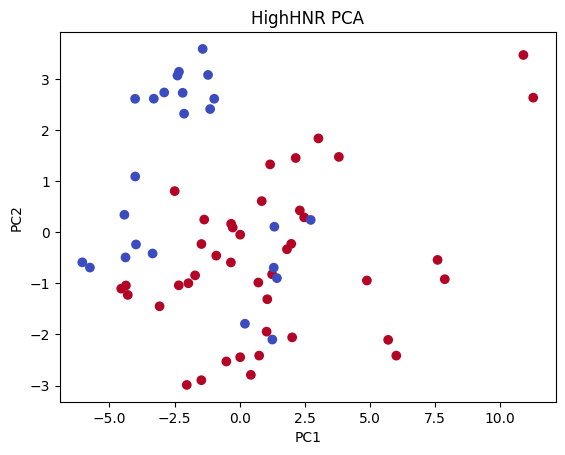

In [6]:
X_pca_high = pca_high.transform(X_high_train_scaled)

import matplotlib.pyplot as plt 

plt.scatter(X_pca_high[:,0], X_pca_high[:,1], c=y_high_train, cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("HighHNR PCA")
plt.savefig("pca_high.png")
plt.show()

In [7]:
from sklearn.decomposition import PCA

#low PCA
pca_low = PCA()
pca_low.fit(X_low_train_scaled)

print("Low PCA Variance (first 7):")
print(pca_low.explained_variance_ratio_[:7])

Low PCA Variance (first 7):
[0.57811751 0.14928313 0.07815793 0.06843312 0.03479762 0.02579099
 0.02039917]


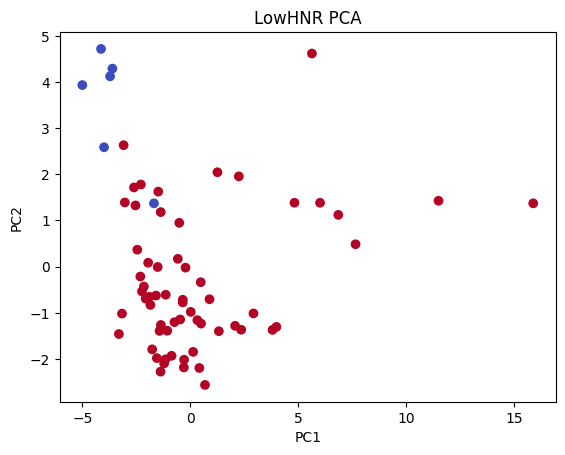

In [8]:
X_pca_low = pca_low.transform(X_low_train_scaled)

import matplotlib.pyplot as plt

plt.scatter(X_pca_low[:,0], X_pca_low[:,1], c=y_low_train, cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LowHNR PCA")
plt.savefig("pca_low.png")
plt.show()

## Task 2: SVM Classification (HighHNR)

In [9]:
from sklearn.model_selection import train_test_split

X_train2, X_val, y_train2, y_val = train_test_split(
    X_high_train_scaled, y_high_train, test_size=0.2, random_state=42
)

print("Train size:", len(X_train2))
print("Validation size:", len(X_val))

Train size: 52
Validation size: 14


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

params = [(1,1), (20,0.5), (0.5,0.1)]

for C, gamma in params:
    model = SVC(C=C, gamma=gamma, kernel='rbf')
    model.fit(X_train2, y_train2)
    preds = model.predict(X_val)
    print("C:", C, "gamma:", gamma, "Accuracy:", accuracy_score(y_val, preds))
    

C: 1 gamma: 1 Accuracy: 0.7857142857142857
C: 20 gamma: 0.5 Accuracy: 0.9285714285714286
C: 0.5 gamma: 0.1 Accuracy: 1.0


In [11]:
from sklearn.metrics import confusion_matrix

#final model
best_model = SVC(C=0.5, gamma=0.1, kernel='rbf')
best_model.fit(X_high_train_scaled, y_high_train)

#predict on test set

test_preds = best_model.predict(X_high_test_scaled)

#results

print("Test Accuracy:", accuracy_score(y_high_test, test_preds))
print("Confusion Matrix:\n", confusion_matrix(y_high_test, test_preds))


Test Accuracy: 0.6129032258064516
Confusion Matrix:
 [[ 0 12]
 [ 0 19]]


## Task 3: SVM Classification (LowHNR)

In [12]:
from sklearn.model_selection import train_test_split

X_train2_low, X_val_low, y_train2_low, y_val_low= train_test_split(
    X_low_train_scaled, y_low_train, test_size=0.2, random_state=42 
)

In [13]:
params = [(1,1), (20,0.5), (0.5,0.1)]

for C, gamma in params:
    model = SVC(C=C, gamma=gamma, kernel='rbf')
    model.fit(X_train2_low, y_train2_low)
    preds = model.predict(X_val_low)
    print("C:", C, "gamma:", gamma, "Accuracy:", accuracy_score(y_val_low, preds))

C: 1 gamma: 1 Accuracy: 0.8571428571428571
C: 20 gamma: 0.5 Accuracy: 0.8571428571428571
C: 0.5 gamma: 0.1 Accuracy: 0.8571428571428571


In [14]:
from sklearn.metrics import confusion_matrix

#final model
best_model_low = SVC(C=1, gamma=1, kernel='rbf')
best_model_low.fit(X_low_train_scaled, y_low_train)

#predict on test set

test_preds_low = best_model_low.predict(X_low_test_scaled)

#results

print("Test Accuracy:", accuracy_score(y_low_test, test_preds_low))
print("Confusion Matrix:\n", confusion_matrix(y_low_test, test_preds_low))


Test Accuracy: 0.8064516129032258
Confusion Matrix:
 [[ 0  6]
 [ 0 25]]


## Task 4: Cross-model Evaluation

In [15]:
X_low_test_scaled_by_high = scaler_high.transform(X_low_test)

preds = best_model.predict(X_low_test_scaled_by_high)

print("Accuracy:", accuracy_score(y_low_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_low_test, preds))

Accuracy: 0.8064516129032258
Confusion Matrix:
 [[ 0  6]
 [ 0 25]]


In [16]:
high_test_scaled_by_low = scaler_low.transform(X_high_test)

preds = best_model_low.predict(high_test_scaled_by_low)

print("Accuracy:", accuracy_score(y_high_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_high_test, preds))

Accuracy: 0.6129032258064516
Confusion Matrix:
 [[ 0 12]
 [ 0 19]]
